In [33]:
!pip install torch torchvision scikit-learn matplotlib seaborn -q
print("GPU available:", torch.cuda.is_available())

GPU available: True


In [47]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import copy
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score, jaccard_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import confusion_matrix



In [35]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/DAT103_Indonesia_Project'

# Updated AOI bounding box
AOI_BBOX = {
    'min_lon': 107.2831,
    'max_lon': 107.3471,
    'min_lat': -6.7023,
    'max_lat': -6.6383
}


PATCHES_DIR = f'{BASE}/data/patches/'
MODELS_DIR = f'{BASE}/models/'
FIGURES_DIR = f'{BASE}/figures/'

for d in [PATCHES_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)
print("Paths ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths ready.


In [36]:

print("Loading patch arrays...")
X_train = np.load(f"{PATCHES_DIR}/X_train.npy")
y_train = np.load(f"{PATCHES_DIR}/y_train.npy")
X_val = np.load(f"{PATCHES_DIR}/X_val.npy")
y_val = np.load(f"{PATCHES_DIR}/y_val.npy")
X_test = np.load(f"{PATCHES_DIR}/X_test.npy")
y_test = np.load(f"{PATCHES_DIR}/y_test.npy")

print(f"Train X: {X_train.shape}, Train y: {y_train.shape}")
print(f"Val X: {X_val.shape}, Val y: {y_val.shape}")
print(f"Test X: {X_test.shape}, Test y: {y_test.shape}")

# We hardcode 7 based on the ESRI mapping (0 is often used for nodata, leaving 1-11 as classes)
ESRI_TO_INDEX = {1: 0, 2: 1, 4: 2, 5: 3, 7: 4, 8: 5, 11: 6}
INDEX_TO_NAME = {0: "Water", 1: "Trees", 2: "Flooded Veg", 3: "Crops", 4: "Built Area", 5: "Bare Ground", 6: "Rangeland"}

def remap_labels(y_array):
    remapped = np.zeros_like(y_array)
    for esri_val, idx in ESRI_TO_INDEX.items():
        remapped[y_array == esri_val] = idx
    return remapped

y_train = remap_labels(y_train)
y_val = remap_labels(y_val)
y_test = remap_labels(y_test)
print("Labels remapped to 0-6 index for PyTorch.")

Loading patch arrays...
Train X: (470, 7, 32, 32), Train y: (470, 32, 32)
Val X: (104, 7, 32, 32), Val y: (104, 32, 32)
Test X: (102, 7, 32, 32), Test y: (102, 32, 32)
Labels remapped to 0-6 index for PyTorch.


In [37]:


NUM_CLASSES = 7
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on device: {DEVICE}")

# --- 1. THE RESIDUAL BLOCK ---
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        # First convolution
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
        # Second convolution
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c)
        )
        self.shortcut = nn.Sequential()
        if in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_c)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x += residual
        return self.relu(x)

# --- 2. THE RES-UNET ARCHITECTURE ---
class LandCoverResUNet(nn.Module):
    def __init__(self, in_channels=7, num_classes=NUM_CLASSES):
        super().__init__()

        # --- ENCODER (Using Residual Blocks) ---
        self.enc1 = ResidualBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ResidualBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # --- BOTTLENECK ---
        self.bottleneck = ResidualBlock(128, 256)

        # --- DECODER (Using Residual Blocks) ---
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ResidualBlock(256, 128) # 128 from upconv + 128 from skip

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ResidualBlock(128, 64) # 64 from upconv + 64 from skip

        # --- FINAL CLASSIFIER ---
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        # Bottleneck
        b = self.bottleneck(self.pool2(e2))

        # Decoder
        d2 = self.upconv2(b)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)

Training on device: cuda


In [38]:


class AugmentedLandCoverDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        mask = self.y[idx]

        if self.augment:
            # 1. Random Horizontal Flip
            if random.random() > 0.5:
                image = torch.flip(image, dims=[2]) # Flip Width (C, H, W)
                mask = torch.flip(mask, dims=[1])   # Flip Width (H, W)

            # 2. Random Vertical Flip
            if random.random() > 0.5:
                image = torch.flip(image, dims=[1]) # Flip Height (C, H, W)
                mask = torch.flip(mask, dims=[0])   # Flip Height (H, W)

            # 3. Random 90-degree Rotations (0, 90, 180, 270)
            k = random.randint(0, 3)
            if k > 0:
                image = torch.rot90(image, k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[0, 1])

        return image, mask

Calculating Log-Smoothed Class Weights...
 Smoothed Weights Applied: [0.896 0.777 1.472 0.823 0.887 0.    1.145]

Starting Hyperparameter Tuning on Validation Set...

Testing Params: {'lr': 0.001, 'batch_size': 32}
  Epoch   5/10 | Loss: 1.0584 | Val mIoU: 0.5116
  Epoch  10/10 | Loss: 1.0110 | Val mIoU: 0.5396

Testing Params: {'lr': 0.0005, 'batch_size': 32}
  Epoch   5/10 | Loss: 1.0865 | Val mIoU: 0.5184
  Epoch  10/10 | Loss: 0.9923 | Val mIoU: 0.5761

 Best Hyperparameters Found: {'lr': 0.0005, 'batch_size': 32, 'val_miou': 0.576058566570282}

Training Final Model with Best Params for 200 Epochs...
  Epoch   5/200 | Loss: 1.0906 | Val mIoU: 0.5093
  Epoch  10/200 | Loss: 1.0157 | Val mIoU: 0.5723
  Epoch  15/200 | Loss: 0.9421 | Val mIoU: 0.5819
  Epoch  20/200 | Loss: 0.8406 | Val mIoU: 0.7007
  Epoch  25/200 | Loss: 0.8246 | Val mIoU: 0.6777
  Epoch  30/200 | Loss: 0.7875 | Val mIoU: 0.7727
  Epoch  35/200 | Loss: 0.7533 | Val mIoU: 0.7957
  Epoch  40/200 | Loss: 0.7347 | Val m

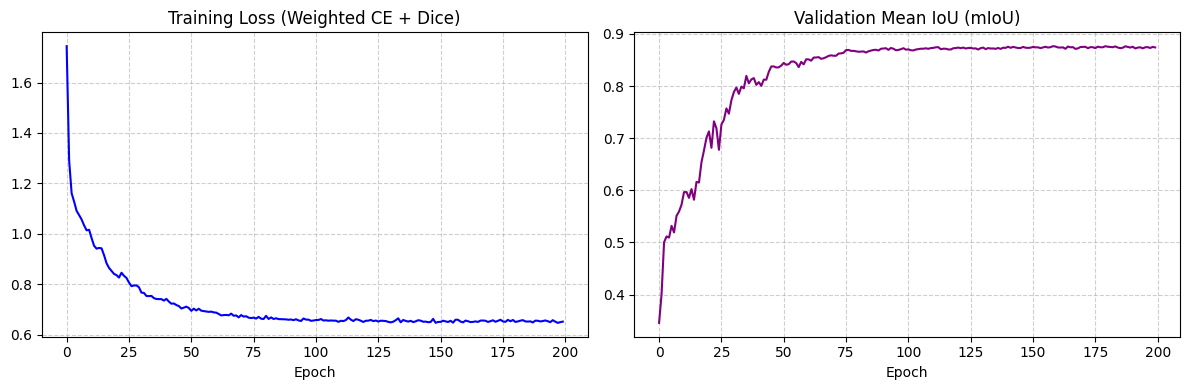

Saved training_curves.png


In [42]:


# --- 1. CALCULATE CLASS WEIGHTS (LOG-SMOOTHED) ---
print("Calculating Log-Smoothed Class Weights...")
class_counts = np.bincount(y_train.flatten(), minlength=NUM_CLASSES)
class_weights = np.zeros(NUM_CLASSES, dtype=np.float32)
valid_classes = class_counts > 0

# Apply Log Smoothing
class_weights[valid_classes] = 1.0 / np.log(1.2 + class_counts[valid_classes])
num_valid = valid_classes.sum()
class_weights[valid_classes] = class_weights[valid_classes] / class_weights[valid_classes].sum() * num_valid

weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f" Smoothed Weights Applied: {np.round(class_weights, 3)}")


# --- 2. THE DICE LOSS ---
def dice_loss(preds, targets, smooth=1e-5):
    preds = F.softmax(preds, dim=1)
    targets_one_hot = F.one_hot(targets, num_classes=NUM_CLASSES).permute(0, 3, 1, 2).float()

    intersection = (preds * targets_one_hot).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))

    dice_score = (2. * intersection + smooth) / (union + smooth)
    return 1.0 - dice_score.mean()


# --- 3. mIoU-OPTIMIZED TRAINING FUNCTION ---
def train_unet(lr=1e-3, batch_size=16, epochs=100):
    train_ds = AugmentedLandCoverDataset(X_train, y_train, augment=True)
    val_ds = AugmentedLandCoverDataset(X_val, y_val, augment=False)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)

    model = LandCoverResUNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Combined Loss: Weighted Cross-Entropy + Dice
    ce_loss = nn.CrossEntropyLoss(weight=weights_tensor)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

    best_val_miou, best_state = 0, None
    train_losses, val_mious = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()

            preds = model(xb)
            loss = ce_loss(preds, yb) + dice_loss(preds, yb)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        intersection = torch.zeros(NUM_CLASSES).to(DEVICE)
        union = torch.zeros(NUM_CLASSES).to(DEVICE)

        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                preds = model(xb).argmax(dim=1)

                for c in range(NUM_CLASSES):
                    pred_c = (preds == c)
                    target_c = (yb == c)
                    intersection[c] += (pred_c & target_c).sum()
                    union[c] += pred_c.sum() + target_c.sum() - (pred_c & target_c).sum()

        # Calculate strict Mean IoU
        valid_val_classes = union > 0
        epoch_miou = (intersection[valid_val_classes] / union[valid_val_classes]).mean().item()

        train_losses.append(total_loss / len(train_dl))
        val_mious.append(epoch_miou)
        scheduler.step()

        if epoch_miou > best_val_miou:
            best_val_miou = epoch_miou
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Loss: {total_loss/len(train_dl):.4f} | Val mIoU: {epoch_miou:.4f}")

    model.load_state_dict(best_state)
    return model, best_val_miou, train_losses, val_mious


# --- 4. HYPERPARAMETER TUNING ---
print("\nStarting Hyperparameter Tuning on Validation Set...")
param_grid = [
    {"lr": 1e-3, "batch_size": 32},
    {"lr": 5e-4, "batch_size": 32}
]

results = []
for params in param_grid:
    print(f"\nTesting Params: {params}")
    _, val_miou, _, _ = train_unet(**params, epochs=10)
    results.append({**params, "val_miou": val_miou})

best_params = max(results, key=lambda x: x['val_miou'])
print(f"\n Best Hyperparameters Found: {best_params}")


# --- 5. TRAIN FINAL MODEL ---
print("\nTraining Final Model with Best Params for 200 Epochs...")
final_unet, best_miou, t_loss, v_mious = train_unet(
    lr=best_params['lr'],
    batch_size=best_params['batch_size'],
    epochs=200
)

torch.save(final_unet.state_dict(), f"{MODELS_DIR}/best_unet.pth")
print(f"Final ResUNet model saved to {MODELS_DIR}/best_unet.pth")


# --- 6. PLOT TRAINING CURVES ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(t_loss, color='blue')
ax1.set_title("Training Loss (Weighted CE + Dice)")
ax1.set_xlabel("Epoch")
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(v_mious, color='purple')  # Changed color to differentiate from accuracy
ax2.set_title("Validation Mean IoU (mIoU)")
ax2.set_xlabel("Epoch")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png")

Running test set predictions for metrics...
 Macro F1 Score (All classes treated equally): 0.9194
 Mean IoU Score (All classes treated equally): 0.8634

Generating ROC curves (Subsampled for RAM safety)...
Skipping ROC for Bare Ground (Not present in Test Set)


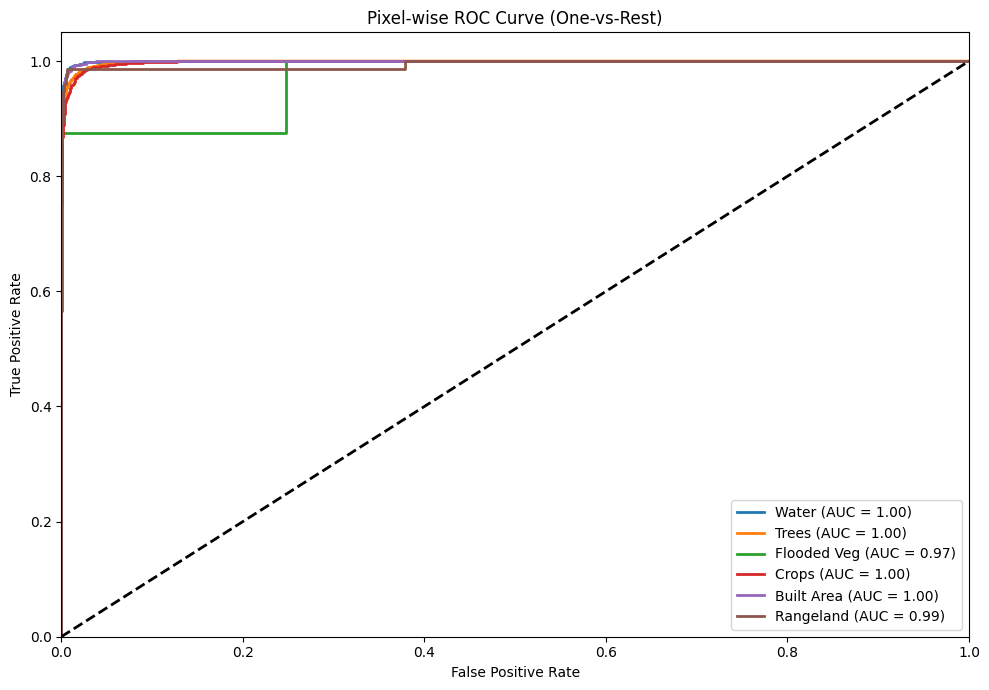

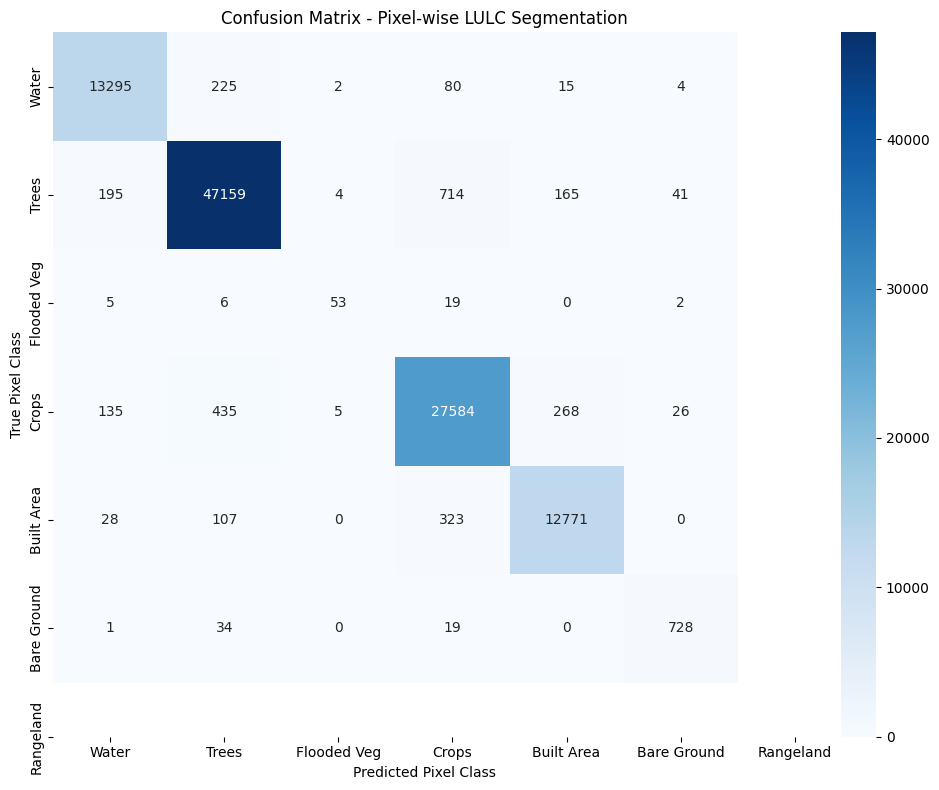

In [43]:

final_unet.eval()
test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
test_dl = DataLoader(test_ds, batch_size=32)

y_true_flat, y_pred_flat = [], []
y_probs_flat = []

print("Running test set predictions for metrics...")
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(DEVICE)

        # Raw model outputs
        raw_output = final_unet(xb)

        # 1. Get class predictions for F1/IoU/CM
        preds = raw_output.argmax(dim=1).cpu().numpy()

        # 2. Get probabilities for ROC
        probs = torch.softmax(raw_output, dim=1).cpu().numpy()
        # Reshape probs from (Batch, Classes, H, W) to (Pixels, Classes)
        probs = np.transpose(probs, (0, 2, 3, 1)).reshape(-1, NUM_CLASSES)

        y_pred_flat.extend(preds.flatten())
        y_true_flat.extend(yb.numpy().flatten())
        y_probs_flat.extend(probs)

y_true_flat = np.array(y_true_flat)
y_pred_flat = np.array(y_pred_flat)
y_probs_flat = np.array(y_probs_flat)

# --- METRIC 1 & 2: MACRO F1 and MACRO IoU ---
f1 = f1_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)
iou = jaccard_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)

print(f" Macro F1 Score (All classes treated equally): {f1:.4f}")
print(f" Mean IoU Score (All classes treated equally): {iou:.4f}")

class_names = ["Water", "Trees", "Flooded Veg", "Crops", "Built Area", "Bare Ground", "Rangeland"]

# --- METRIC 3: ROC Curve  ---
print("\nGenerating ROC curves (Subsampled for RAM safety)...")

# SUBSAMPLING FIX: Take every 10th pixel to prevent Colab RAM crashes
step = 10
y_true_sub = y_true_flat[::step]
y_probs_sub = y_probs_flat[::step]

y_bin = label_binarize(y_true_sub, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(NUM_CLASSES):
    # Only plot if the class actually exists in the test set
    if np.sum(y_bin[:, i]) > 0:
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs_sub[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")
    else:
        print(f"Skipping ROC for {class_names[i]} (Not present in Test Set)")

ax.plot([0, 1], [0, 1], 'k--', lw=2)
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Pixel-wise ROC Curve (One-vs-Rest)')
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/roc_curve.png", dpi=150)
plt.show()

# --- METRIC 4: Confusion Matrix ---
cm = confusion_matrix(y_true_flat, y_pred_flat)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel("Predicted Pixel Class"); ax.set_ylabel("True Pixel Class")
ax.set_title("Confusion Matrix - Pixel-wise LULC Segmentation")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/confusion_matrix.png", dpi=150)
plt.show()

In [44]:


print("Evaluating Final Model on the Unseen Test Set...")
final_unet.eval()

all_preds = []
all_labels = []

# 1. Gather all predictions from the Test Set
with torch.no_grad():
    test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
    test_dl = DataLoader(test_ds, batch_size=16)

    for xb, yb in test_dl:
        xb = xb.to(DEVICE)
        preds = final_unet(xb).argmax(dim=1).cpu().numpy()

        all_preds.append(preds.flatten())
        all_labels.append(yb.numpy().flatten())

# Flatten arrays to calculate metrics pixel-by-pixel
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# 2. Calculate the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels=range(NUM_CLASSES))

# 3. Calculate Per-Class IoU and Mean IoU
ious = []
print("\n--- PER-CLASS IoU BREAKDOWN ---")

class_names = ["Water", "Trees", "Flooded Veg", "Crops", "Built Area", "Bare Ground", "Rangeland"]

for i in range(NUM_CLASSES):
    intersection = cm[i, i]
    union = cm[i, :].sum() + cm[:, i].sum() - intersection

    if union == 0:
        print(f"Class {i} ({class_names[i]:<12}): Not present in Test Set")
        ious.append(np.nan) # Ignore missing classes in the mean
    else:
        iou = intersection / union
        ious.append(iou)
        print(f"Class {i} ({class_names[i]:<12}): {iou:.4f}")

# 4. The Final "Normal" mIoU
mean_iou = np.nanmean(ious)
print("-" * 31)
print(f"Mean IoU (mIoU)  : {mean_iou:.4f}")

Evaluating Final Model on the Unseen Test Set...

--- PER-CLASS IoU BREAKDOWN ---
Class 0 (Water       ): 0.9507
Class 1 (Trees       ): 0.9608
Class 2 (Flooded Veg ): 0.5521
Class 3 (Crops       ): 0.9316
Class 4 (Built Area  ): 0.9338
Class 5 (Bare Ground ): Not present in Test Set
Class 6 (Rangeland   ): 0.8515
-------------------------------
Mean IoU (mIoU)  : 0.8634


Visualizing 3 random test predictions...


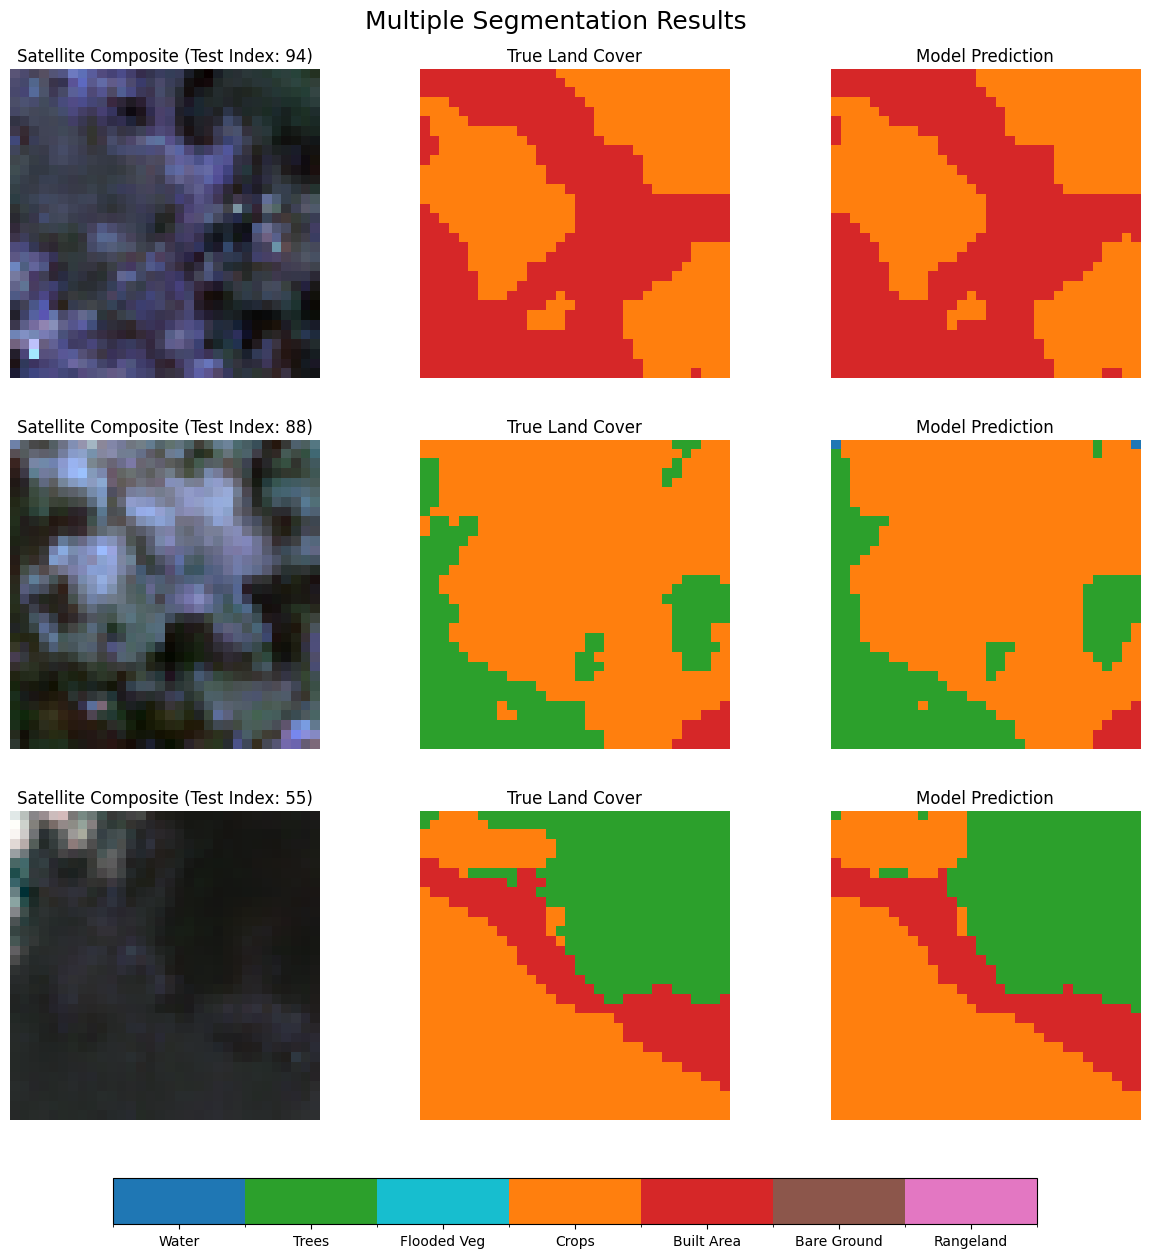

In [50]:


num_examples = 3
print(f"Visualizing {num_examples} random test predictions...")

# --- 1. SETUP COLORMAP FOR 7 CLASSES ---
hex_colors = ['#1f77b4', '#2ca02c', '#17becf', '#ff7f0e', '#d62728', '#8c564b', '#e377c2']
cmap = mcolors.ListedColormap(hex_colors)
norm = mcolors.BoundaryNorm(np.arange(-0.5, NUM_CLASSES), cmap.N)

# --- 2. CREATE SUBPLOT GRID ---
fig, axes = plt.subplots(num_examples, 3, figsize=(15, 5 * num_examples))
final_unet.eval()

for i in range(num_examples):
    # --- SELECT RANDOM SAMPLE ---
    idx = random.randint(0, len(X_test) - 1)
    test_image = X_test[idx]
    true_mask = y_test[idx]

    # --- GENERATE PREDICTION ---
    with torch.no_grad():
        img_tensor = torch.FloatTensor(test_image).unsqueeze(0).to(DEVICE)
        pred_mask = final_unet(img_tensor).argmax(dim=1).squeeze(0).cpu().numpy()

    # --- PREPARE RGB COMPOSITE ---
    rgb_img = test_image[[0, 1, 2], :, :].transpose(1, 2, 0)
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-5)

    # --- PLOT THE RESULTS FOR THIS ROW ---
    # Plot 1: Satellite Composite
    axes[i, 0].imshow(rgb_img)
    axes[i, 0].set_title(f"Satellite Composite (Test Index: {idx})")
    axes[i, 0].axis('off')

    # Plot 2: True Mask
    im1 = axes[i, 1].imshow(true_mask, cmap=cmap, norm=norm, interpolation='nearest')
    axes[i, 1].set_title("True Land Cover")
    axes[i, 1].axis('off')

    # Plot 3: Predicted Mask
    im2 = axes[i, 2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation='nearest')
    axes[i, 2].set_title("Model Prediction")
    axes[i, 2].axis('off')

# --- 3. ADD SHARED COLORBAR ---
cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.04, pad=0.05)
cbar.set_ticks(range(NUM_CLASSES))
cbar.set_ticklabels(["Water", "Trees", "Flooded Veg", "Crops", "Built Area", "Bare Ground", "Rangeland"])

plt.suptitle("Multiple Segmentation Results", fontsize=18, y=0.92)
plt.savefig(f"{FIGURES_DIR}/prediction_multiple_samples.png", dpi=150, bbox_inches='tight')
plt.show()